---
## Section 1 — Setup & Imports

In [ ]:
!pip install xgboost umap-learn --quiet

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score, f1_score,
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
)
from xgboost import XGBClassifier
import umap

# ── Must match preprocessing notebook ─────────────────────────────────────────
TARGET_SIZE  = (64, 64)
RANDOM_STATE = 42
TEST_SIZE    = 0.20

np.random.seed(RANDOM_STATE)   # ensures identical random plots for everyone
print('Imports OK.')

Imports OK.


---
## Section 2 — Mount Drive & Load Preprocessed Data

Set `DRIVE_LOAD_PATH` to the same shared folder used in the preprocessing notebook.

In [ ]:
from pathlib import Path

# -- Local path to your synced shared Google Drive folder
DATA_DIR = Path('/Users/silingguo/Library/CloudStorage/GoogleDrive-siling.guo@sjsu.edu/Shared drives/MATH 250: Traffic Sign Classification')

# -- Load feature matrix, labels, and class names
X       = np.load(DATA_DIR / 'X.npy')
y       = np.load(DATA_DIR / 'y.npy')
classes = np.load(DATA_DIR / 'le_classes.npy', allow_pickle=True)
meta_df = pd.read_csv(DATA_DIR / 'crop_metadata.csv')

# Reconstruct LabelEncoder from saved classes
le = LabelEncoder()
le.classes_ = classes

# Keep DRIVE_LOAD_PATH for compatibility with later cells
DRIVE_LOAD_PATH = str(DATA_DIR)

print(f'X shape   : {X.shape}')
print(f'y shape   : {y.shape}')
print(f'Classes   : {len(classes)} -> {classes}')
print(f'Meta rows : {len(meta_df)}')

X shape   : (29512, 4096)
y shape   : (29512,)
Classes   : 46 -> ['addedLane' 'curveLeft' 'curveRight' 'dip' 'doNotEnter' 'doNotPass'
 'intersection' 'keepRight' 'laneEnds' 'merge' 'noLeftTurn' 'noRightTurn'
 'pedestrianCrossing' 'rampSpeedAdvisory20' 'rampSpeedAdvisory35'
 'rampSpeedAdvisory45' 'rampSpeedAdvisory50' 'rampSpeedAdvisoryUrdbl'
 'rightLaneMustTurn' 'roundabout' 'school' 'schoolSpeedLimit25'
 'signalAhead' 'slow' 'speedLimit15' 'speedLimit25' 'speedLimit30'
 'speedLimit35' 'speedLimit40' 'speedLimit45' 'speedLimit50'
 'speedLimit55' 'speedLimit65' 'speedLimitUrdbl' 'stop' 'stopAhead'
 'thruMergeLeft' 'thruMergeRight' 'thruTrafficMergeLeft'
 'truckSpeedLimit55' 'turnLeft' 'turnRight' 'yield' 'yieldAhead'
 'zoneAhead25' 'zoneAhead45']
Meta rows : 29512


---
## Section 3 — Train / Test Split

**Use `RANDOM_STATE=42` and `stratify=y` here.**  
Because everyone loads the same `X` and `y` from Drive and uses the same seed,  
all members get **identical** train/test splits even in separate Colab sessions.

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size    = TEST_SIZE,
    random_state = RANDOM_STATE,
    stratify     = y
)

print(f'Training : {X_train.shape[0]:,} samples')
print(f'Test     : {X_test.shape[0]:,} samples')
print(f'Features : {X_train.shape[1]:,}')

Training : 23,609 samples
Test     : 5,903 samples
Features : 4,096


In [ ]:
# Apply SMOTE only to training data to handle imbalanced data. Set seed for reproducibility.
from imblearn.over_sampling import SMOTE
sm = SMOTE(random_state = 42)
X_train, y_train = sm.fit_resample(X_train, y_train)

NameError: name 'X_train' is not defined

---
## Section 4 — Shared Plots & Evaluation Helper

Run these cells once.  The plots are loaded from the PNGs saved to Drive  
during preprocessing — everyone sees the exact same figures.

In [ ]:
# ── Display shared preprocessing plots from Drive ─────────────────────────────
plot_files = [
    ('plot_class_distribution.png',    'Class Distribution (before augmentation)'),
    ('plot_class_dist_augmented.png',  'Class Distribution (after augmentation)'),
    ('plot_sample_grid.png',           'Sample Grid — one crop per class'),
    ('plot_augmentation_examples.png', 'Augmentation Examples'),
    ('plot_crop_size_dist.png',        'Original Crop Size Distribution'),
]

for fname, title in plot_files:
    fpath = os.path.join(DRIVE_LOAD_PATH, fname)
    if os.path.exists(fpath):
        img = plt.imread(fpath)
        fig, ax = plt.subplots(figsize=(14, 5))
        ax.imshow(img)
        ax.axis('off')
        ax.set_title(title, fontsize=12)
        plt.tight_layout()
        plt.show()
    else:
        print(f'  [missing] {fname} — run preprocessing notebook first')

  [missing] plot_class_distribution.png — run preprocessing notebook first
  [missing] plot_class_dist_augmented.png — run preprocessing notebook first
  [missing] plot_sample_grid.png — run preprocessing notebook first
  [missing] plot_augmentation_examples.png — run preprocessing notebook first
  [missing] plot_crop_size_dist.png — run preprocessing notebook first


In [ ]:
# ── Evaluation helper ─────────────────────────────────────────────────────────
def evaluate_model(model_name, y_true, y_pred, class_names=None, plot_cm=True,
                   save_path=None):
    """
    Compute accuracy, balanced accuracy, and macro F1-score.
    Optionally display and save a normalised confusion matrix.

    Parameters
    ----------
    model_name  : str   — shown in output header
    y_true      : array — ground-truth integer labels
    y_pred      : array — predicted integer labels
    class_names : list  — human-readable strings (pass le.classes_)
    plot_cm     : bool  — display the confusion matrix
    save_path   : str   — if given, save the confusion matrix PNG here

    Returns dict with keys 'accuracy', 'balanced_accuracy', 'f1_macro'
    """
    acc     = accuracy_score(y_true, y_pred)
    bal_acc = balanced_accuracy_score(y_true, y_pred)
    f1      = f1_score(y_true, y_pred, average='macro', zero_division=0)

    sep = '=' * 58
    print(f'\n{sep}')
    print(f'  {model_name}')
    print(sep)
    print(f'  Accuracy          : {acc:.4f}')
    print(f'  Balanced Accuracy : {bal_acc:.4f}  <- primary metric')
    print(f'  Macro F1-Score    : {f1:.4f}')
    print()
    print(classification_report(y_true, y_pred,
                                target_names=class_names, zero_division=0))

    if plot_cm:
        cm  = confusion_matrix(y_true, y_pred, normalize='true')
        fig, ax = plt.subplots(figsize=(14, 12))
        ConfusionMatrixDisplay(cm, display_labels=class_names).plot(
            ax=ax, xticks_rotation=45, colorbar=True, cmap='Blues'
        )
        ax.set_title(f'Normalised Confusion Matrix\n{model_name}')
        plt.tight_layout()
        if save_path:
            plt.savefig(save_path, dpi=150)
            print(f'  Saved CM: {save_path}')
        plt.show()

    return {'model': model_name, 'accuracy': acc,
            'balanced_accuracy': bal_acc, 'f1_macro': f1}


print('evaluate_model() ready.')

evaluate_model() ready.


---
## Section 5A — PCA + Classifiers
*(Member 1 runs this section)*

PCA finds the directions of maximum variance in the 4,096-dimensional pixel space.  
We choose `n_components` so that 95% of total variance is retained,  
then fit on the training set only and apply the same transform to the test set.

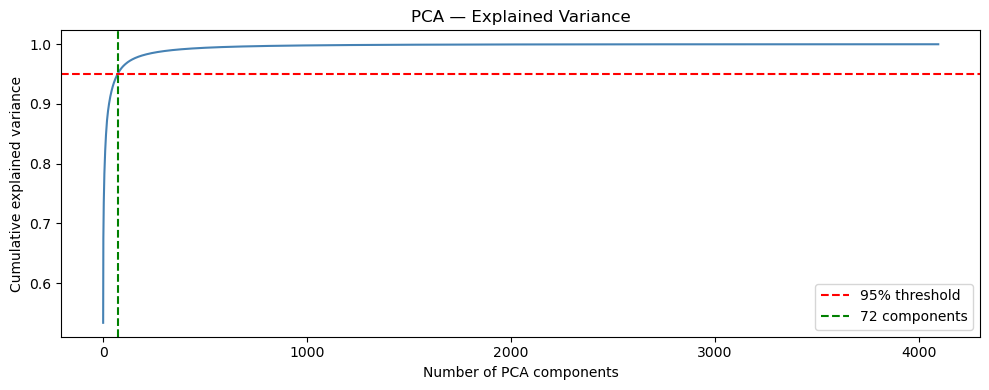

Components for 95% variance: 72
X_train_pca: (237268, 72)  |  X_test_pca: (5903, 72)


In [ ]:
# ── Fit PCA and choose n_components ───────────────────────────────────────────
pca_full = PCA(random_state=RANDOM_STATE).fit(X_train)
cumvar   = np.cumsum(pca_full.explained_variance_ratio_)
n_pca    = int(np.searchsorted(cumvar, 0.95)) + 1

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(cumvar, color='steelblue')
ax.axhline(0.95, color='red',   linestyle='--', label='95% threshold')
ax.axvline(n_pca, color='green', linestyle='--', label=f'{n_pca} components')
ax.set_xlabel('Number of PCA components')
ax.set_ylabel('Cumulative explained variance')
ax.set_title('PCA — Explained Variance')
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(DRIVE_LOAD_PATH, 'plot_pca_variance.png'), dpi=150)
plt.show()
print(f'Components for 95% variance: {n_pca}')

pca         = PCA(n_components=n_pca, random_state=RANDOM_STATE)
X_train_pca = pca.fit_transform(X_train)
X_test_pca  = pca.transform(X_test)
print(f'X_train_pca: {X_train_pca.shape}  |  X_test_pca: {X_test_pca.shape}')


  PCA + Naive Bayes
  Accuracy          : 0.7074
  Balanced Accuracy : 0.7370  <- primary metric
  Macro F1-Score    : 0.6888

                        precision    recall  f1-score   support

             addedLane       0.82      0.63      0.71       222
             curveLeft       0.30      0.43      0.36        30
            curveRight       0.15      0.65      0.24        40
                   dip       0.85      0.82      0.84        28
            doNotEnter       0.73      0.89      0.80        18
             doNotPass       1.00      1.00      1.00         7
          intersection       1.00      1.00      1.00         1
             keepRight       0.96      0.83      0.89       262
              laneEnds       0.59      0.63      0.61       158
                 merge       0.55      0.47      0.51       213
            noLeftTurn       0.84      0.77      0.81        35
           noRightTurn       0.95      0.90      0.93        21
    pedestrianCrossing       0.82      

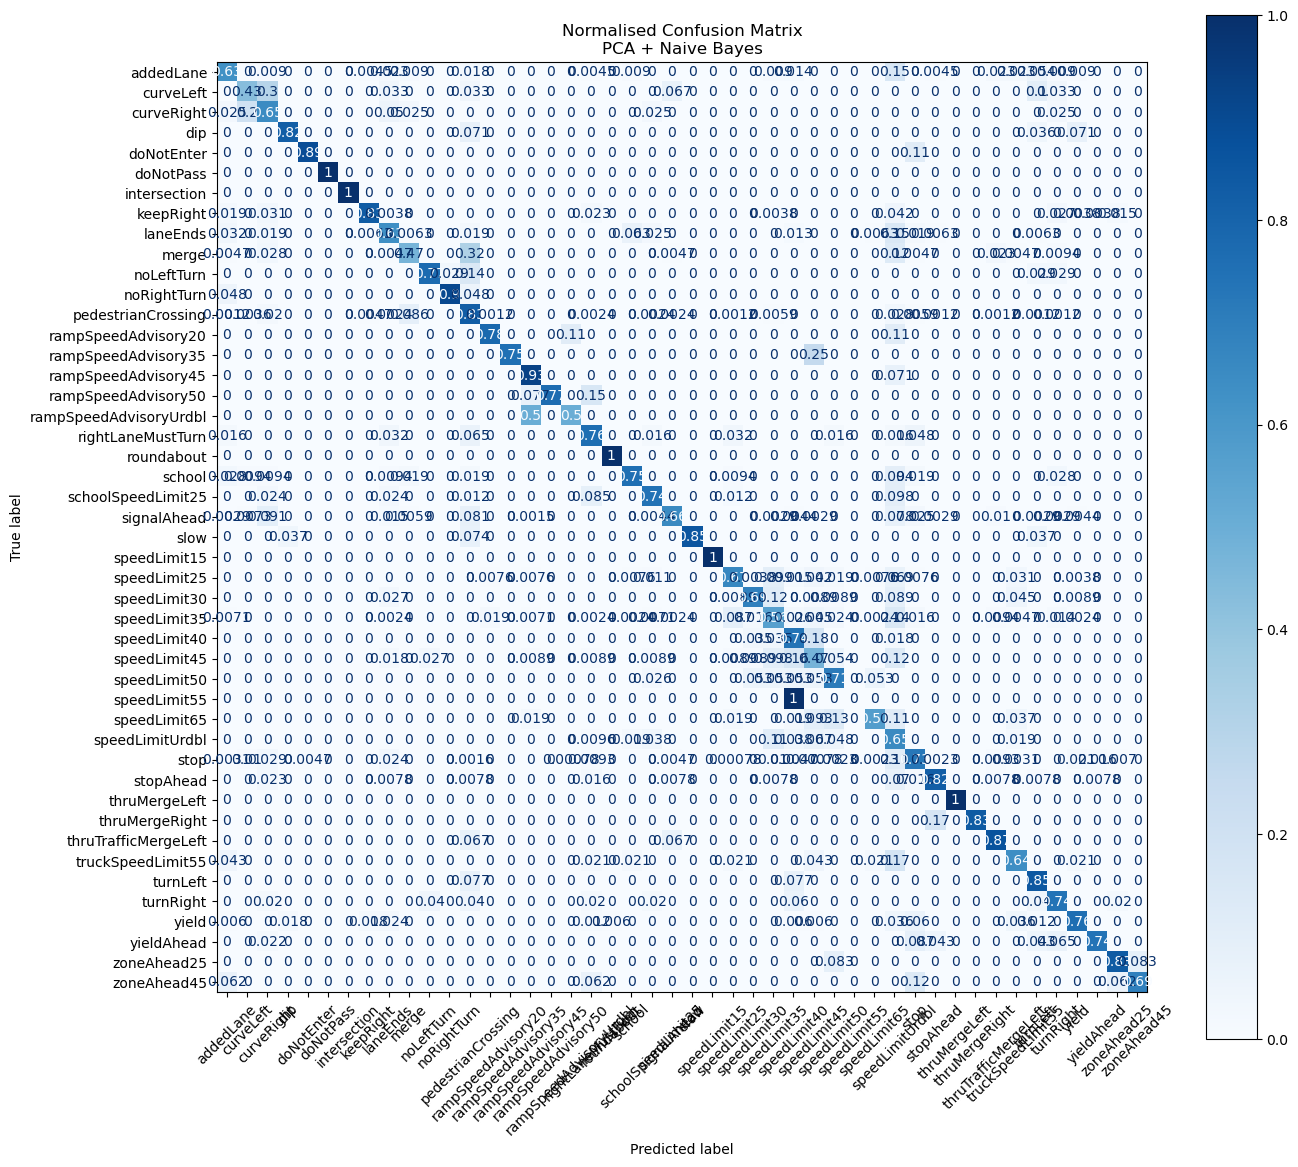

In [ ]:
# ── PCA + Naive Bayes ─────────────────────────────────────────────────────────
nb_pca = GaussianNB()
nb_pca.fit(X_train_pca, y_train)
r_nb_pca = evaluate_model(
    'PCA + Naive Bayes', y_test, nb_pca.predict(X_test_pca),
    class_names=le.classes_,
    save_path=os.path.join(DRIVE_LOAD_PATH, 'cm_pca_nb.png')
)

---
## Section 5C — t-SNE + Classifiers
*(Member 3 runs this section)*

**Key difference from PCA/SVD:** `TSNE` has no `.transform()` method,  
so we cannot embed the test set after fitting on train.  
Instead we embed the full dataset `X` **before** the split,  
then split the resulting 2-D coordinates the same way as `X`.

We pre-reduce to 50 PCA dimensions first (standard practice) to speed up t-SNE.

Pre-reducing with PCA (50 components)...
X_pre shape: (29512, 50)
Running t-SNE on full dataset (may take a few minutes)...
X_tsne shape: (29512, 2)


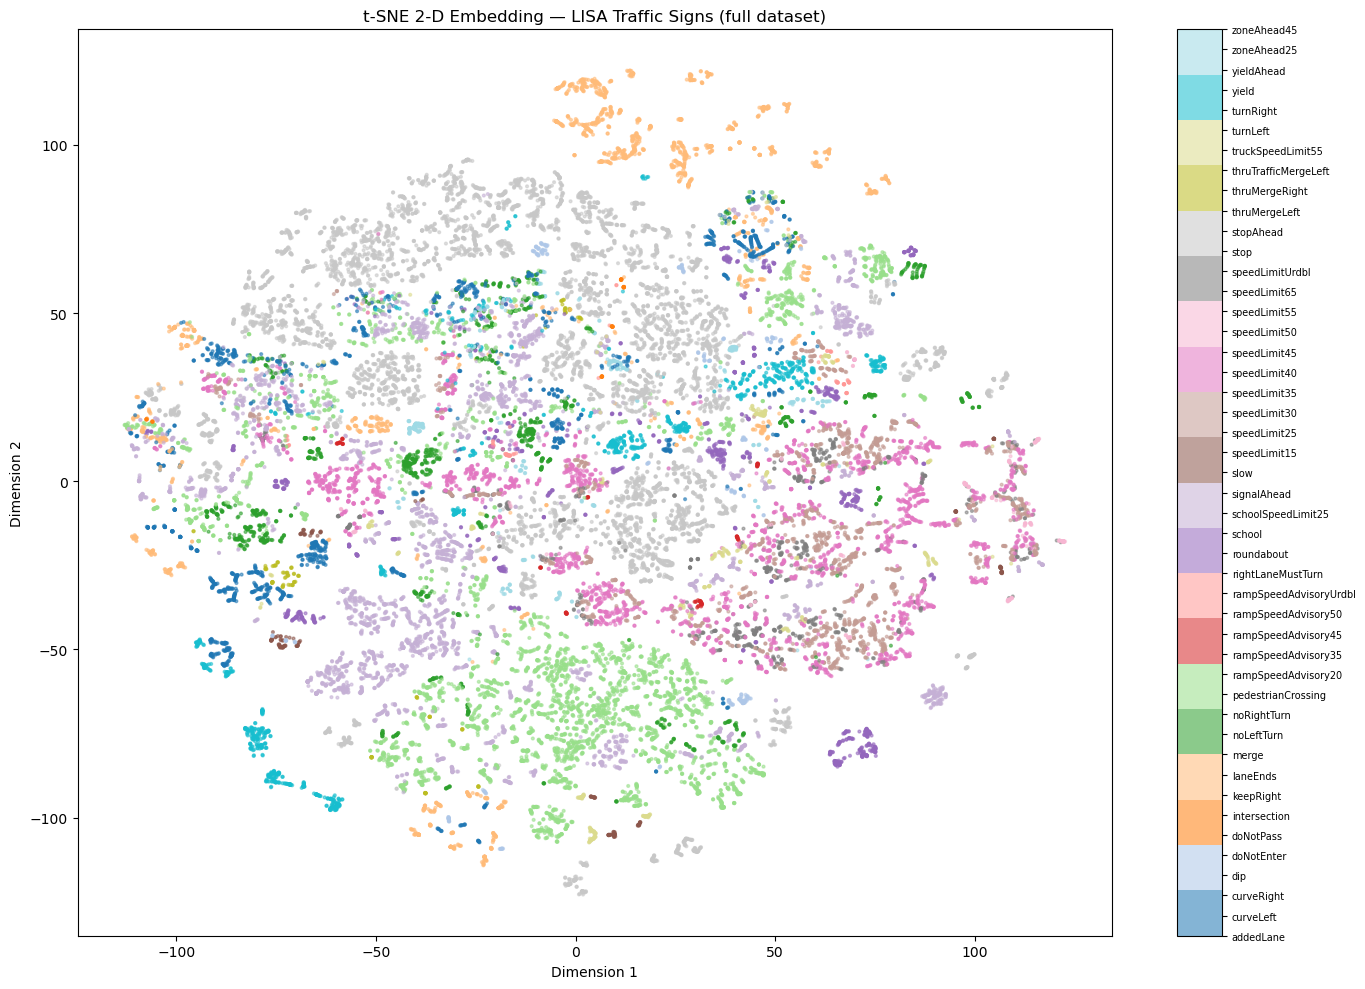

Saved: plot_tsne_embedding.png


In [ ]:
# ── Step 1: Pre-reduce to 50 dims with PCA before t-SNE ───────────────────────
print('Pre-reducing with PCA (50 components)...')
pca_pre  = PCA(n_components=50, random_state=RANDOM_STATE)
X_pre    = pca_pre.fit_transform(X)
print(f'X_pre shape: {X_pre.shape}')

# ── Step 2: Run t-SNE on full dataset ─────────────────────────────────────────
print('Running t-SNE on full dataset (may take a few minutes)...')
tsne   = TSNE(n_components=2, perplexity=30, random_state=RANDOM_STATE, n_jobs=-1)
X_tsne = tsne.fit_transform(X_pre)
print(f'X_tsne shape: {X_tsne.shape}')

# ── Step 3: Visualise the 2-D embedding ───────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 10))
scatter = ax.scatter(
    X_tsne[:, 0], X_tsne[:, 1],
    c=y, cmap='tab20', s=4, alpha=0.55
)
cbar = plt.colorbar(scatter, ax=ax, ticks=range(len(le.classes_)))
cbar.ax.set_yticklabels(le.classes_, fontsize=7)
ax.set_title('t-SNE 2-D Embedding — LISA Traffic Signs (full dataset)')
ax.set_xlabel('Dimension 1')
ax.set_ylabel('Dimension 2')
plt.tight_layout()
plt.savefig(os.path.join(DRIVE_LOAD_PATH, 'plot_tsne_embedding.png'), dpi=150)
plt.show()
print('Saved: plot_tsne_embedding.png')

In [ ]:
# ── Step 4: Split t-SNE embeddings with the same seed & stratify ──────────────
# Using the same RANDOM_STATE and stratify=y ensures this split
# is consistent with the X_train/X_test split in Section 3.
X_train_tsne, X_test_tsne, y_train_tsne, y_test_tsne = train_test_split(
    X_tsne, y,
    test_size    = TEST_SIZE,
    random_state = RANDOM_STATE,
    stratify     = y
)
print(f'Train t-SNE: {X_train_tsne.shape}  |  Test t-SNE: {X_test_tsne.shape}')

Train t-SNE: (23609, 2)  |  Test t-SNE: (5903, 2)


In [ ]:
# Apply SMOTE only to training data to handle imbalanced data. Set seed for reproducibility.
from imblearn.over_sampling import SMOTE
sm = SMOTE(random_state = 42)
X_train_tsne, y_train_tsne = sm.fit_resample(X_train_tsne, y_train_tsne)


  t-SNE + Random Forest
  Accuracy          : 0.9283
  Balanced Accuracy : 0.9257  <- primary metric
  Macro F1-Score    : 0.8548

                        precision    recall  f1-score   support

             addedLane       0.88      0.86      0.87       222
             curveLeft       0.58      0.73      0.65        30
            curveRight       0.91      0.97      0.94        40
                   dip       0.79      0.93      0.85        28
            doNotEnter       0.75      1.00      0.86        18
             doNotPass       1.00      0.71      0.83         7
          intersection       1.00      1.00      1.00         1
             keepRight       0.99      0.99      0.99       262
              laneEnds       0.91      0.89      0.90       158
                 merge       0.87      0.84      0.85       213
            noLeftTurn       0.94      0.97      0.96        35
           noRightTurn       0.75      1.00      0.86        21
    pedestrianCrossing       0.98  

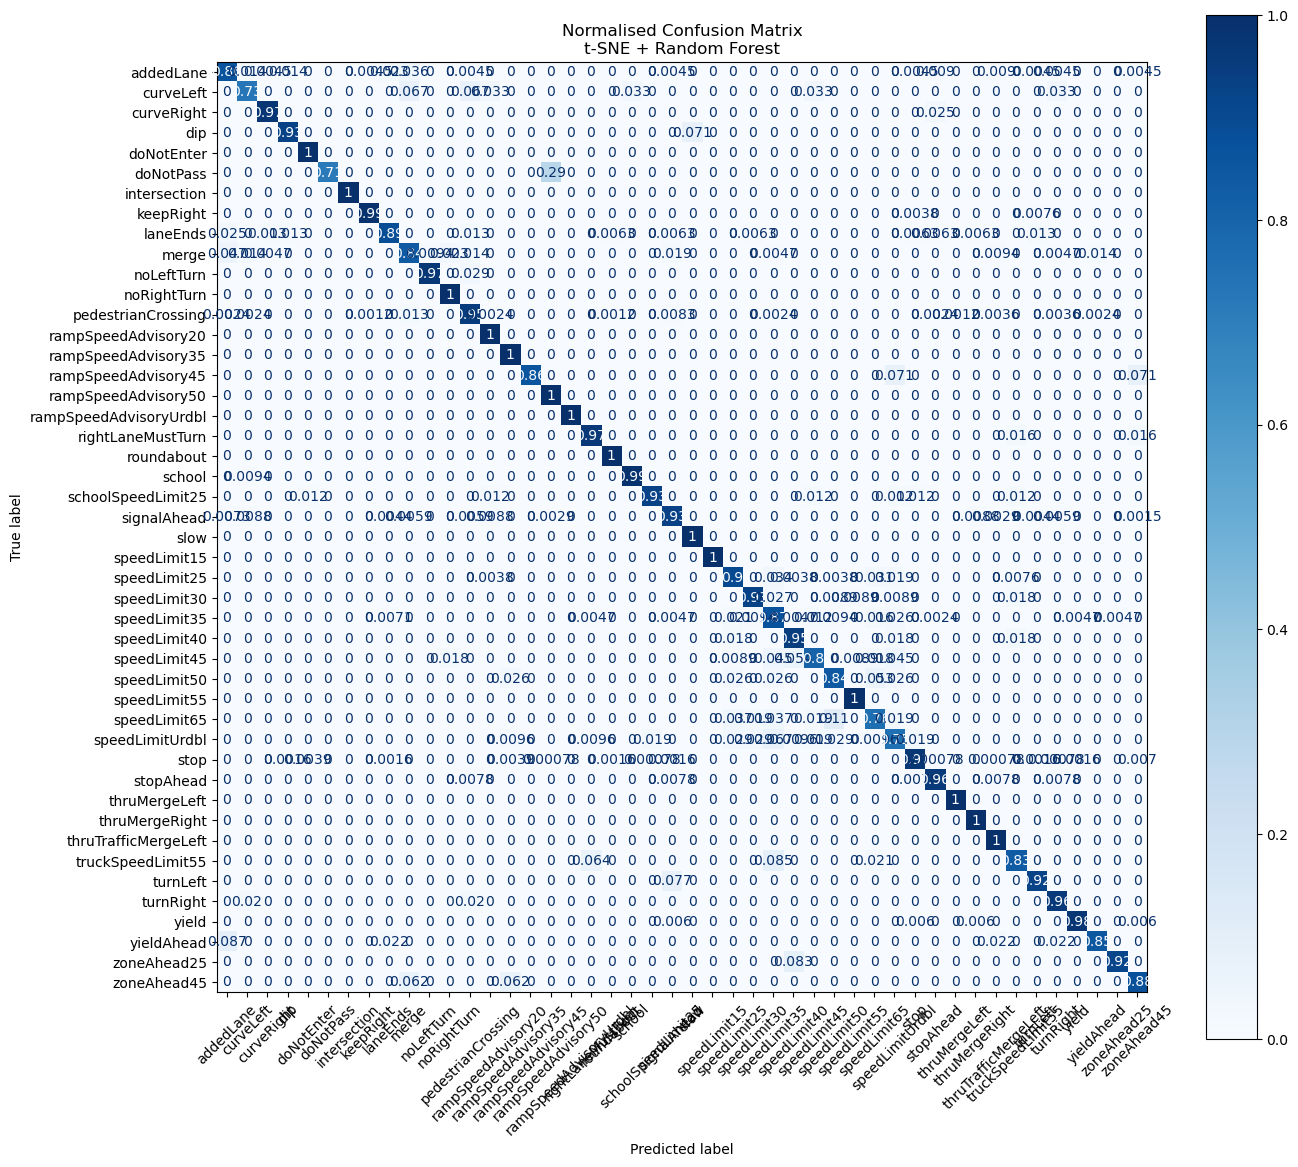

In [ ]:
# -- t-SNE + Random Forest
rf_tsne = RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE, n_jobs=-1)
rf_tsne.fit(X_train_tsne, y_train_tsne)
r_rf_tsne = evaluate_model(
    't-SNE + Random Forest', y_test_tsne, rf_tsne.predict(X_test_tsne),
    class_names=le.classes_,
    save_path=os.path.join(DRIVE_LOAD_PATH, 'cm_tsne_rf.png')
)

---
## Section 6 — Results Summary

Combine whichever result lists are available in this session into a ranked table.  
The table and bar chart are saved to Drive so the full team can compare results.

In [ ]:

tsne_results = [r_rf_tsne]

                model  Accuracy  Balanced Accuracy  Macro F1
t-SNE + Random Forest  0.928342           0.925741  0.854807


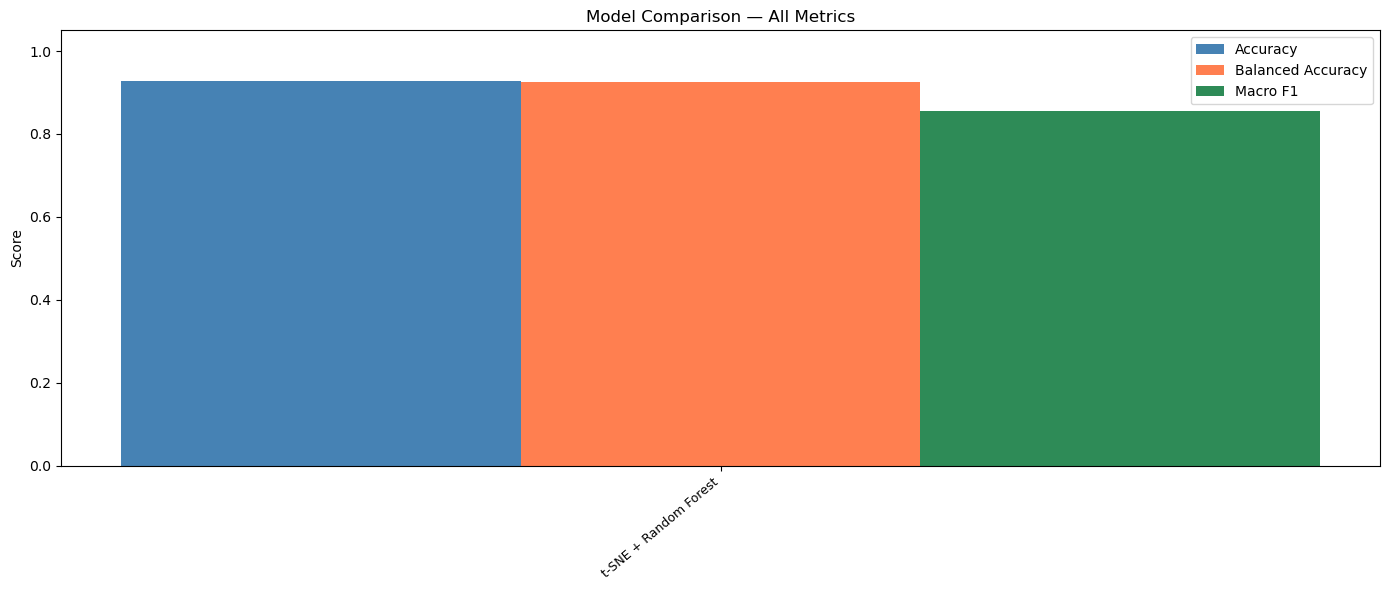

Saved: plot_results_summary.png
Saved: results_summary.csv


In [ ]:
# ── Collect whichever results exist in this session ───────────────────────────
all_results = []
for var_name in ['tsne_results']:
    if var_name in dir():
        all_results.extend(eval(var_name))

if not all_results:
    print('No results collected yet — run a section in 5A, 5B, or 5C first.')
else:
    summary = pd.DataFrame(all_results).sort_values('balanced_accuracy', ascending=False)
    summary = summary.rename(columns={
        'accuracy': 'Accuracy',
        'balanced_accuracy': 'Balanced Accuracy',
        'f1_macro': 'Macro F1'
    })

    print(summary[['model','Accuracy','Balanced Accuracy','Macro F1']].to_string(index=False))

    # ── Bar chart ─────────────────────────────────────────────────────────────
    fig, ax = plt.subplots(figsize=(14, 6))
    x     = np.arange(len(summary))
    width = 0.28
    ax.bar(x - width, summary['Accuracy'],          width, label='Accuracy',          color='steelblue')
    ax.bar(x,         summary['Balanced Accuracy'], width, label='Balanced Accuracy', color='coral')
    ax.bar(x + width, summary['Macro F1'],          width, label='Macro F1',          color='seagreen')
    ax.set_xticks(x)
    ax.set_xticklabels(summary['model'], rotation=40, ha='right', fontsize=9)
    ax.set_ylabel('Score')
    ax.set_ylim(0, 1.05)
    ax.set_title('Model Comparison — All Metrics')
    ax.legend()
    plt.tight_layout()
    plt.savefig(os.path.join(DRIVE_LOAD_PATH, 'plot_results_summary.png'), dpi=150)
    plt.show()
    print('Saved: plot_results_summary.png')

    # Save CSV
    out_csv = os.path.join(DRIVE_LOAD_PATH, 'results_summary.csv')
    summary.to_csv(out_csv, index=False)
    print(f'Saved: results_summary.csv')